# DSN Doppler Noise Analysis — Daily RMS vs Solar Elongation

This notebook computes the daily Doppler noise level from DSN tracking data of Venus Express (VEX) for a given year.

The goal is to characterise the large-scale behaviour of the Doppler signal as a function of solar elongation (SEP), and to compare it with theoretical expectations for solar plasma scintillation.

---

## Method

The processing steps are:

1. Load raw DSN Doppler data
2. Apply filtering:
   - valid data only
   - elevation > threshold
   - Doppler outlier removal
3. Convert Doppler (Hz) → velocity (mm/s)
4. Compute daily RMS values
5. Merge with daily solar elongation from JPL Horizons
6. Apply smoothing to reveal long-term trends
7. Compare against DSN theoretical scintillation model

---

## Output

This notebook produces:

- `daily_metrics_<year>.csv`
- Daily Doppler RMS vs SEP plots

These outputs form the large-scale baseline for later phase scintillation analysis.

In [25]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from config.settings_2014 import *

deBug= True
sav_file = True

from src.io_utils import load_dsn_data, load_horizons_daily_sep
from src.doppler_utils import prepare_daily_rms_table, print_daily_summary
from src.plot_utils import plot_daily_rms_vs_sep

In [27]:
horizons_daily = load_horizons_daily_sep(HORIZONS_FILE)

df = load_dsn_data(
    DOPPLER_FILE,
    valid_only=USE_VALID_FLAG,
    min_elev_deg=MIN_ELEV_DEG,
    max_abs_doppler_hz=MAX_ABS_DOPPLER_HZ,
)
if deBug == True:
    print("Horizons daily rows:", len(horizons_daily))
    print("Horizons time range:", horizons_daily["day"].min(), "→", horizons_daily["day"].max())
    
    print("DSN rows after filtering:", len(df))
    print("DSN time range:", df["UTC_time"].min(), "→", df["UTC_time"].max())


daily_df = prepare_daily_rms_table(
    dsn_df=df,
    horizons_daily=horizons_daily,
    f_carrier_hz=F_CARRIER,
    c_mps=C,
    T_int_sec=T_INT,
    C_band=C_BAND,
    resample_rule=RESAMPLE_RULE,
    min_samples_per_day=MIN_SAMPLES_PER_DAY,
    smooth_days=SMOOTH_DAYS,
    add_tropo_diagnostic=USE_TROPO_DIAGNOSTIC,
)

if deBug == True:
    print_daily_summary(daily_df)
    
    daily_df.head()

Horizons daily rows: 365
Horizons time range: 2014-01-01 00:00:00 → 2014-12-31 00:00:00
DSN rows after filtering: 91642
DSN time range: 2014-01-01 10:07:53.112000 → 2014-02-08 13:34:59.074000

Daily RMS rows: 38
Daily RMS time range: 2014-01-01 00:00:00 → 2014-02-08 00:00:00
Measured Doppler RMS range (mm/s): 0.02760242831316936 → 0.1670368505281591
Missing SEP after daily merge: 0
SEP range (deg): 5.0595 → 35.1335


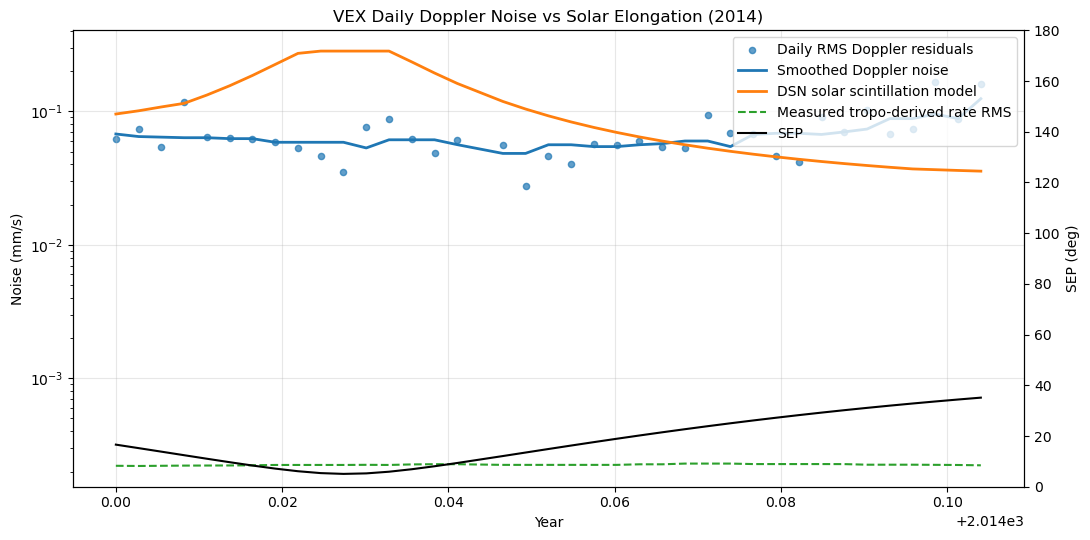

In [28]:
fig, axes = plot_daily_rms_vs_sep(daily_df, year=YEAR)
plt.show()

In [29]:
if sav_file ==True:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    daily_csv = OUTPUT_DIR / f"daily_metrics_{YEAR}.csv"
    daily_df.to_csv(daily_csv, index=False)
    
    print("Saved:", daily_csv)
if deBug == True:
    print(daily_df.columns.tolist())
    daily_df.tail()

Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/daily_metrics_2014.csv
['day', 'doppler_rms_mm_s', 'n_60s_samples', 'tropo_rate_rms', 'elongation_deg', 'solar_model_mm_s', 'decimal_year', 'doppler_smooth_mm_s', 'solar_smooth_mm_s', 'tropo_smooth']
